Лабораторная работа  посвящена работе с библиотекой `sklearn`, которая позволяет использовать основные методы машинного обучения.

Рекомендуется выполнять лабораторную работу в Google Colab с использованием браузера. Если на вашем компьютере установлена Anaconda, вы можете скачать задание и выполнять его с использованием Anaconda.



# **Лабораторная работа. Линейная регрессия.**

В самом начале работы следут подключить нужные нам библиотеки. Для удобства мы не будем подключать всю библиотеку `sklearn` сразу целиком, а будем подключать только отдельные модули по мере необходимости.

In [59]:
# Нам потребуются библиотеки, которые мы использовали в предыдущих лабораторных
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Для выполнения последующих заданий в Google Colab потребуется подключить работу с гугл-диском, запустив следующую ячейку. [Инструкция по подключению и работе с файлами в Google Colab](https://colab.research.google.com/drive/1DOwvT_j7OIkjZoNL4LwbXxDwmYUn0TLm?usp=sharing).

**Внимание! Если вы выполняете работу в Anaconda, следующую ячейку запускать не нужно!**

Перед выполнением следующих заданий вам нужно загрузить на свой гугл-диск файлы `winequality-red.csv`. 

**Если вы работаете в Anaconda, файлы нужно скачать на компьютер и поместить в папку, из которой вам будет удобно с ними работать.**

## **Линейная регрессия**

Задания 1-7 посвящены решению задачи линейной регрессии. 

**Задание 1.** Загрузите набор данных `winequality-red.csv` в качестве датафрейма. Результат сохраните в переменную `winequality_data`. Выведите на экран верхнюю часть таблицы (используйте `head()`). Выведите размеры набора данных (используйте `shape`).

In [60]:
# Подключение нужных библиотечных модулей для машинного обучения
from sklearn.linear_model import LinearRegression  # Линейная регрессия
from sklearn import datasets, linear_model

winequality_data = pd.read_csv('winequality-red.csv', sep=';')
winequality_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Задание 2**. Постройте матрицу корреляции для проверки взаимосвязи различных параметров. Проанализируйте полученную матрицу и запишите выводы.

Можно использовать готовый код ниже.

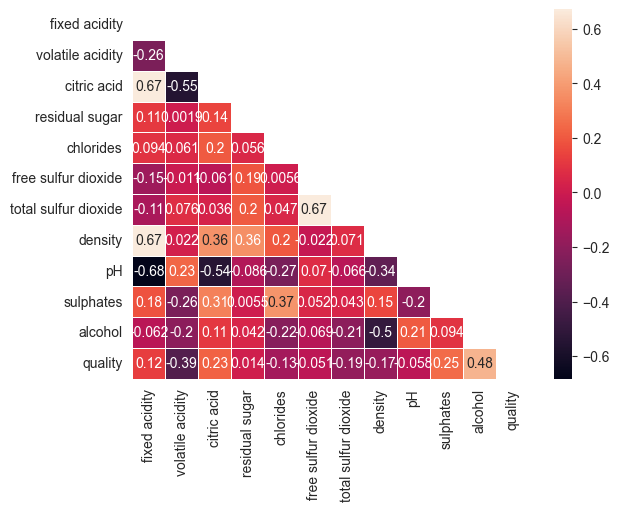

In [61]:
# Запустите эту ячейку!
import seaborn as sns
new_columns = winequality_data.columns.values.tolist()
corr = winequality_data[new_columns].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
  ax = sns.heatmap(corr, mask=mask, square=False, cbar=True, annot=True, linewidths=.5)

Проанализуйте полученную матрицу корреляции и перечислите 2-3 параметра, которые имеют **максимальную** корреляцию друг с другом. Необходимо сравнивать **модули значений**. Опишите характер корреляции:

- До 0,2 по модулю — очень слабая корреляция
- До 0,5 по модулю — слабая
- До 0,7 по модулю — средняя
- До 0,9 по модулю — высокая
- Больше 0,9 по модулю — очень высокая
- Если коэффициент корреляции положительный, то корреляция **прямая** (положительная), если отрицательный, то **обратная** (отрицательная).

**Пример**: для столбцов `Название_1` и `Название_2` коэффициент корреляции равен -0.53, что означает среднюю отрицательную корреляцию.

In [62]:
"""
Максимальные коэффициенты корреляции имеют:
1. fixed acidity и pH. -0.68 - средняя обратная корреляция
2. free sulfur dioxide и total sulfur dioxide. 0.67 - средняя прямая корреляция
3. volatile acidity и citric acid. -0.55 - средняя обратная корреляция

"""

'\nМаксимальные коэффициенты корреляции имеют:\n1. fixed acidity и pH. -0.68 - средняя обратная корреляция\n2. free sulfur dioxide и total sulfur dioxide. 0.67 - средняя прямая корреляция\n3. volatile acidity и citric acid. -0.55 - средняя обратная корреляция\n\n'

**Задание 3.** Выполните подготовку загруженных данных. Для этого датафрейм нужно разбить две части: на входные данные (их мы обозначаем как `X`) и правильные ответы (обозначаем как `y`).

Чтобы разделить данные, можно воспользоваться следующим примером:

`x = df.loc[:, ['Параметр1', 'Параметр2']]`

Ваша задача для входных данных указать один или несколько параметров, которые будут участвовать в обучении модели. Выбор нужно делать на основе построенной матрицы корреляции и сделанных выводов. Для правильных ответов также нужно указать один из параметров.

**Примечание:** для упрощения модели регрессии в переменную `Х` можно перенести один-два столбца датафрейма, а в переменной `у` в любом случае будет только один столбец. Вам необходимо самостоятельно выбрать, какие столбцы будут использоваться в качестве входных параметров, а какой в качестве целевой функции. Используйте результаты корреляционного анализа, выполненного при решении предыдущей задачи.

In [63]:
y = winequality_data.loc[:, 'quality']
X = winequality_data.loc[:, ['alcohol', 'volatile acidity']]

**Задание 4.** Разделите набор данных на обучающую `train` и тестовую `test` выборки. В тестовую выборку необходимо поместить 200 значений, все остальные должны быть в обучающей выборке.  

**Примечание:** ниже дана заготовка кода, которую нужно доработать.

In [64]:
# Разделяем выборку на обучающую и тестовую, в тестовой будут 200 значений
x_train = X[:-200]
x_test = X[-200:]

# Аналогично разделяем целевые переменные
y_train = y[:-200]
y_test = y[-200:]

**Задание 5.** Загрузите модель линейной регрессии `LinearRegression()`, а затем запустите ее на обучение `.fit`. Переменную для хранения модели необходимо назвать `model`.

In [65]:
model = LinearRegression()
model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Задание 6**. Проверьте работу обученной модели на тестовых данных и посмотрите точность ее работы (обуснуйте выбранные метрики качества). 
 - Можете использовать представленный ниже код
 - Интерпретируйте результат (напишите в ячейку ниже)

In [66]:
from sklearn.metrics import mean_squared_error, r2_score # Метрики

predictions = model.predict(x_test)

print("Mean squared error: %.2f" % mean_squared_error(y_test, predictions))
print('Variance score: %.2f' % r2_score(y_test, predictions))

Mean squared error: 0.51
Variance score: 0.25


In [67]:
"""
Корень из Mean squared error примерно равен 0.71. Это означает что среднее отклонение от правильного ответа +- 0.71. Для прогнозирования качества вина это довольно много.
Выбранные предикторы (alcohol и volatile acidity) объясняют 25% вариативности в оценке качества вина. Это указывает на наличие статистической связи, однако большая часть дисперсии обусловлена другими факторами.

"""

'\nНапишите сюда, что означают полученные цифры\n\n\n'

**Задание 7.** Постройте точечную диаграмму `scatter` в зависимости `x_test` от `y_test`, а также `plot` в зависимости `x_test` от `predictions`. Интерпретируйте полученные результаты.

**Примечание:** если вы считаете, что все делаете правильно, но при этом построение графика вызывает ошибку, попробуйте в задании 2 оставить в х только один столбец и перезапустить все последующие ячейки.

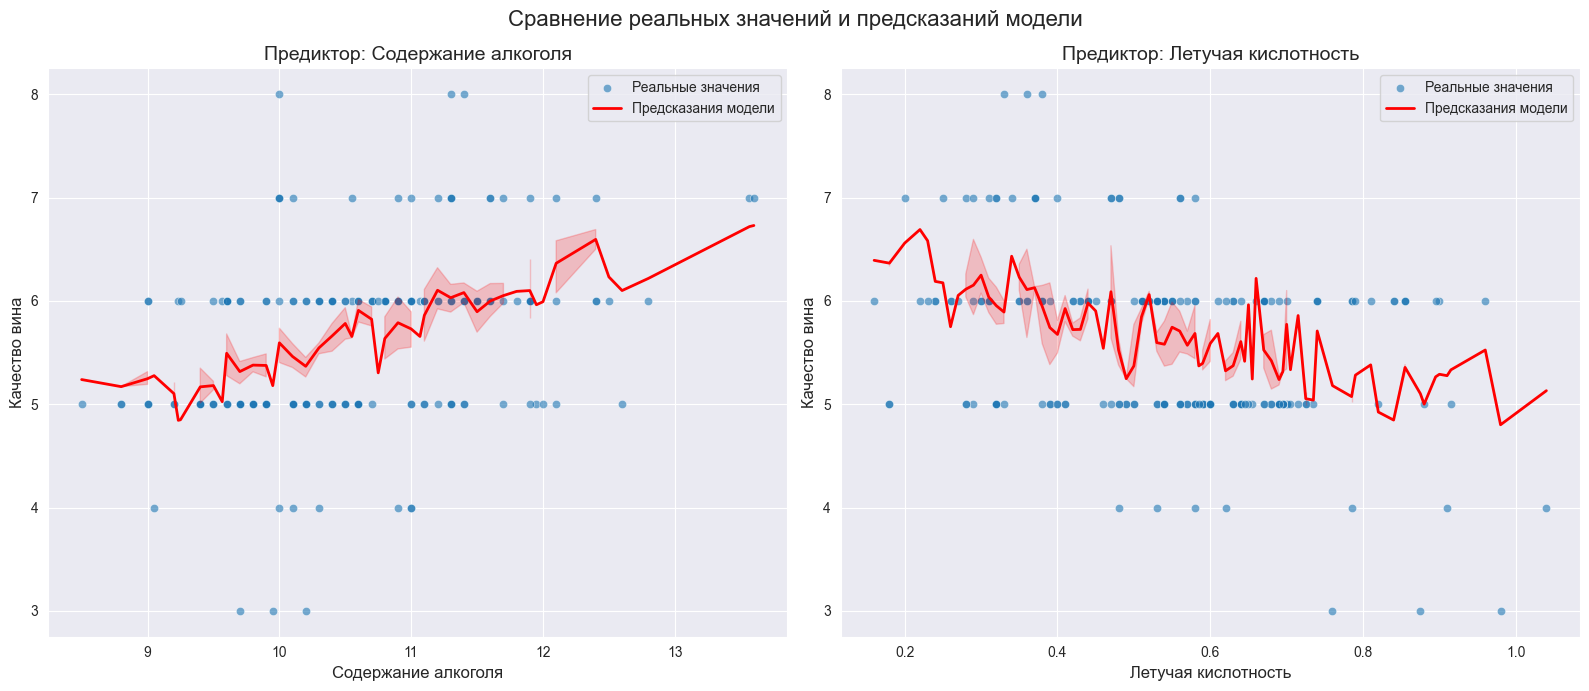

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Сравнение реальных значений и предсказаний модели', fontsize=16)

# --- 1. График для 'alcohol' ---
sort_indices = np.argsort(x_test['alcohol'])
x_test_sorted_alc = x_test['alcohol'].iloc[sort_indices]
predictions_sorted_alc = predictions[sort_indices]

sns.scatterplot(x=x_test['alcohol'], y=y_test, ax=axes[0], alpha=0.6, label='Реальные значения')

sns.lineplot(x=x_test_sorted_alc, y=predictions_sorted_alc, ax=axes[0], color='red', linewidth=2, label='Предсказания модели')

axes[0].set_title('Предиктор: Содержание алкоголя', fontsize=14)
axes[0].set_xlabel('Содержание алкоголя', fontsize=12)
axes[0].set_ylabel('Качество вина', fontsize=12)
axes[0].legend()
axes[0].grid(True)


# --- 2. График для 'volatile acidity' ---
sort_indices_va = np.argsort(x_test['volatile acidity'])
x_test_sorted_va = x_test['volatile acidity'].iloc[sort_indices_va]
predictions_sorted_va = predictions[sort_indices_va]

sns.scatterplot(x=x_test['volatile acidity'], y=y_test, ax=axes[1], alpha=0.6, label='Реальные значения')

sns.lineplot(x=x_test_sorted_va, y=predictions_sorted_va, ax=axes[1], color='red', linewidth=2, label='Предсказания модели')

axes[1].set_title('Предиктор: Летучая кислотность', fontsize=14)
axes[1].set_xlabel('Летучая кислотность', fontsize=12)
axes[1].set_ylabel('Качество вина', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
"""
Как видим, модель правильно поняла общую тенденцию для каждого параметра, то есть возрастающую для alcohol и убывающую для volatile acidity. Большинство значений предсказаний оказались между значениями 5 и 6, что соответствует тому что большинство вин оказались или с качеством 5, или с качеством 6. Однако крайне малое количество предсказаний попало строго в значения 5 или 6. Вывод - текущая модель неточная и требует улучшения.
"""